## Alumno: Rubén Gaona Pérez

## 01MIAR - Actividad Video Valencia Pollution

## NumPy y Pandas

### Objetivos:
- Aplicar diferentes técnicas de tratamiento de estructuras numéricas con Numpy y datos estructurados con Pandas.

### Instrucciones:
- Mantener una estructura limpia, comentando código y secuenciando los apartados con el código correspondiente que resuelva la actividad.
- Como criterio de evaluación se tendrá en cuenta el resultado, la consecución del mismo, estilo, comentarios y adecuación. Siempre será tenido en cuenta cualquier detalle técnico avanzado o no visto en clase relacionado con el tema (explicar el porqué y usabilidad).
- No está permitido compartir los resultados ni el código en ninguno de los foros.
- Revisar los temas así como las sesiones sobre Numpy y Pandas para aplicar dichos contenidos.
- Proponer las respuestas en las celdas a dicho efecto en cada punto, si se necesitan más celdas añadirlas en su sitio correspondiente
- Mostrar de manera clara la respuesta a las preguntas, mediante código

### Entrega:
- Este mismo notebook con las respuetas

### Evaluación
- Esta actividad corresponde con el 10% de la nota final de la asignatura.

### Fecha Realización
- Convocatoria 1 - 05/12/2025 00:00 - 06/12/2025 23:59

#### Descripción
El conjunto de datos "valencia_pollution_dataset.csv" (fichero disponible adjunto a la actividad) proviene de una descarga de datos del servicio web del ayuntamiento de la ciudad de Valencia de datos abiertos.

Los datos recabados de este servicio web son de mediciones cada hora de una serie de estaciones de contaminación atmosférica.

https://valencia.opendatasoft.com/explore/dataset/estacions-contaminacio-atmosferiques-estaciones-contaminacion-atmosfericas/information/

Cada estación realiza una serie de mediciones acerca de la calidad del aire, y de ciertas sustancias que se consideran importantes para analizar la contaminación atmosférica en la ciudad.

#### Columnas para trabajar:
- objectid: id de la estación
- nombre: nombre de la estación
- dirección: dirección de la estación
- tipozona: tipo de la zona, urbana o sub urbana
- parámetros: parámetroe medidos
- mediciones: fichero de mediciones
- tipoemision: tráfico o fondo
- so2: niveles de dióxido de azufre
- no2: niveles de dióxido de nitrogeno
- o3: niveles de ozono
- co: niveles de monóxido de carbono
- pm10: niveles de partículas en suspensión hasta 10um
- pm25: niveles de partículas en suspensión hasta 2,5um
- fecha_carga: timestamp de la actualización de los datos
- calidad_ambiental: estimación de la calidad del aire
- fiwareid: 
- geo_shape: coordenadas geográficas
- geo_point_2d: latitud-longitud

In [18]:
# Importamos la librería numpy con el identificador "np"
# Importamos la librería pandas con el identificador "pd"
# Importamos la librería os
# Importamos la librería seaborn con el identificador "sns"
# Importamos la librería matplotlib.pyplot con el identificador "plt"

import numpy as np
import pandas as pd
import os  
import seaborn as sns     
import matplotlib.pyplot as plt

## 01
Carga de datos de csv (valencia_pollution_dataset.csv) en un DataFrame

In [19]:
# Se le asigna a la variable ruta la ruta del csv
ruta=os.path.join("valencia_pollution_dataset.csv")

# Lee el csv y se ve información básica, como la memoria usada
pollution_dataset=pd.read_csv(ruta)
pollution_dataset.info()
display(pollution_dataset.sample(5))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396 entries, 0 to 395
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   objectid           396 non-null    int64  
 1   nombre             396 non-null    object 
 2   direccion          396 non-null    object 
 3   tipozona           396 non-null    object 
 4   parametros         0 non-null      float64
 5   mediciones         0 non-null      float64
 6   so2                216 non-null    float64
 7   no2                396 non-null    int64  
 8   o3                 216 non-null    float64
 9   co                 108 non-null    float64
 10  pm10               288 non-null    float64
 11  pm25               288 non-null    float64
 12  tipoemision        396 non-null    object 
 13  fecha_carga        396 non-null    object 
 14  calidad_ambiental  396 non-null    object 
 15  fiwareid           0 non-null      float64
 16  geo_shape          0 non-n

,objectid,nombre,direccion,tipozona,parametros,mediciones,so2,no2,o3,co,pm10,pm25,tipoemision,fecha_carga,calidad_ambiental,fiwareid,geo_shape,geo_point_2d
161,26,Pista de Silla,"C/ Filipinas, s/n",Urbana,NaN,NaN,0.0,14,64.0,0.7,7.0,2.0,Tráfico,2025-05-25T13:20:09+00:00,Razonablemente Buena,NaN,NaN,NaN
341,22,Centro,Plaza Ayuntamiento,Urbana,NaN,NaN,NaN,12,NaN,NaN,15.0,8.0,Tráfico,2025-05-26T06:20:12+00:00,Buena,NaN,NaN,NaN
41,22,Centro,Plaza Ayuntamiento,Urbana,NaN,NaN,NaN,7,NaN,NaN,15.0,8.0,Tráfico,2025-05-25T01:20:10+00:00,Buena,NaN,NaN,NaN
170,22,Centro,Plaza Ayuntamiento,Urbana,NaN,NaN,NaN,21,NaN,NaN,15.0,8.0,Tráfico,2025-05-25T14:20:10+00:00,Buena,NaN,NaN,NaN
359,22,Centro,Plaza Ayuntamiento,Urbana,NaN,NaN,NaN,13,NaN,NaN,15.0,8.0,Tráfico,2025-05-26T07:20:10+00:00,Buena,NaN,NaN,NaN


In [20]:
# Al analizar el dataset, se ve que hay posibles columnas enteras de "NaN", por lo que se eliminan por simplicidad y uso de memoria
pollution_dataset=pollution_dataset.dropna(axis=1, how="all")
pollution_dataset.info()
display(pollution_dataset.sample(5))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396 entries, 0 to 395
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   objectid           396 non-null    int64  
 1   nombre             396 non-null    object 
 2   direccion          396 non-null    object 
 3   tipozona           396 non-null    object 
 4   so2                216 non-null    float64
 5   no2                396 non-null    int64  
 6   o3                 216 non-null    float64
 7   co                 108 non-null    float64
 8   pm10               288 non-null    float64
 9   pm25               288 non-null    float64
 10  tipoemision        396 non-null    object 
 11  fecha_carga        396 non-null    object 
 12  calidad_ambiental  396 non-null    object 
dtypes: float64(5), int64(2), object(6)
memory usage: 40.3+ KB


,objectid,nombre,direccion,tipozona,so2,no2,o3,co,pm10,pm25,tipoemision,fecha_carga,calidad_ambiental
343,431,Olivereta,Av. del Cid amb Av. de les Tres Creus,Urbana,NaN,29,NaN,NaN,20.0,11.0,Tráfico,2025-05-26T06:20:14+00:00,Razonablemente Buena
376,27,Universidad Politécnica,Campus de la U. Politécnica. Avda. Tarongers,Suburbana,2.0,3,43.0,NaN,18.0,13.0,Fondo,2025-05-26T09:20:07+00:00,Razonablemente Buena
148,22,Centro,Plaza Ayuntamiento,Urbana,NaN,10,NaN,NaN,14.0,8.0,Tráfico,2025-05-25T12:20:11+00:00,Buena
272,24,Boulevar Sur,Avda. Tres Cruces s/n (Parking Cementerio de V...,Urbana,1.0,4,87.0,NaN,NaN,NaN,Tráfico,2025-05-25T23:20:05+00:00,Razonablemente Buena
94,24,Boulevar Sur,Avda. Tres Cruces s/n (Parking Cementerio de V...,Urbana,2.0,6,71.0,NaN,NaN,NaN,Tráfico,2025-05-25T07:20:05+00:00,Razonablemente Buena


## 02
- ¿Cuál es el rango temporal del dataset?
- Obtención del número de estaciones que tienen un sensor para medir monóxido de carbono

In [21]:
# Rango temporal

# Se cambia el formato de la columna fecha_carga a una con la que se pueda trabajar
pollution_dataset['fecha_carga'] = pd.to_datetime(pollution_dataset['fecha_carga'])

# Se obtienen las fechas máxima y mínima
fecha_min=pollution_dataset["fecha_carga"].min()
fecha_max=pollution_dataset["fecha_carga"].max() 

print(f"El rango temporal del dataset es de {fecha_min} hasta el {fecha_max}")

El rango temporal del dataset es de 2025-05-24 20:20:04+00:00 hasta el 2025-05-26 10:20:13+00:00


In [22]:
# Número de estaciones con sensor para medir CO

# Filtrar filas con sensor de CO
estaciones_co=pollution_dataset[pollution_dataset["co"].notna()]
display(estaciones_co.head())

,objectid,nombre,direccion,tipozona,so2,no2,o3,co,pm10,pm25,tipoemision,fecha_carga,calidad_ambiental
0,26,Pista de Silla,"C/ Filipinas, s/n",Urbana,0.0,10,71.0,0.7,8.0,3.0,Tráfico,2025-05-24 20:20:06+00:00,Razonablemente Buena
4,23,Francia,"Avda. de Francia, 60",Urbana,1.0,3,82.0,0.1,9.0,6.0,Tráfico,2025-05-24 20:20:04+00:00,Razonablemente Buena
9,25,Molí del Sol,Avda. Pío Baroja - Avda. General Avilés,Suburbana,4.0,6,76.0,0.3,7.0,5.0,Tráfico,2025-05-24 20:20:05+00:00,Razonablemente Buena
11,25,Molí del Sol,Avda. Pío Baroja - Avda. General Avilés,Suburbana,4.0,5,77.0,0.3,7.0,5.0,Tráfico,2025-05-24 23:20:06+00:00,Razonablemente Buena
15,26,Pista de Silla,"C/ Filipinas, s/n",Urbana,0.0,4,73.0,0.7,8.0,3.0,Tráfico,2025-05-24 23:20:07+00:00,Razonablemente Buena


In [23]:
# Número de estaciones únicas que tienen sensor CO
num_estaciones_co=estaciones_co["objectid"].nunique()

print(f"El número de estaciones en Valencia que tienen un sensor para medir monóxido de carbono es de {num_estaciones_co}")

El número de estaciones en Valencia que tienen un sensor para medir monóxido de carbono es de 3


## 03

- Número de estación con la media más alta de mediciones de monóxido de carbono

In [24]:
# Agrupando según el object id y calculando la media sobre el co, obtenemos un dataset con la media de cada estación.   
medias_por_estacion = pollution_dataset.groupby("objectid")["co"].mean()

# Se obtiene la media más alta y el índice
valor_co_max=medias_por_estacion.max()
estacion_co_max=medias_por_estacion.idxmax()

print(f"Obtenemos que la estación con media más alta es la del ID {estacion_co_max}, con un valor de {valor_co_max}")



Obtenemos que la estación con media más alta es la del ID 26, con un valor de 0.7


## 04
Realizar el histograma de dióxido de nitrógeno de la estación del punto anterior

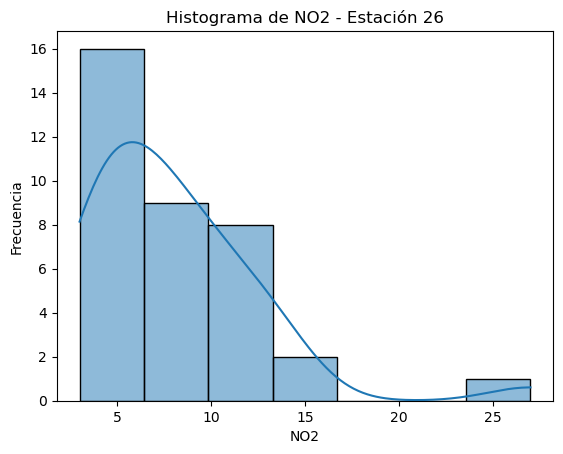

In [25]:
# Cargamos todas las filas que pertenezcan al ObjectID 26 con todas las columnas del NO2
no2_estacion_26=pollution_dataset[pollution_dataset["objectid"]==estacion_co_max]["no2"].dropna()

# Se realiza el histograma, junto con una curva para ver la distribución real.
sns.histplot(no2_estacion_26, kde=True)
plt.xlabel("NO2")
plt.ylabel("Frecuencia")
plt.title("Histograma de NO2 - Estación 26")
plt.show()

## 05
Realizar gráfica con  la línea temporal de las mediciones de ozono de la estación del punto anterior. Pista, la columna 'fecha_carga' habría que cambiarla de tipo.

In [26]:
# Convertimos las fechas mediante la función to_datetime para poder ordenarlas
pollution_dataset_fechas_ordenadas = pollution_dataset.sort_values("fecha_carga")
display(pollution_dataset_fechas_ordenadas.head())
display(pollution_dataset_fechas_ordenadas.tail())

,objectid,nombre,direccion,tipozona,so2,no2,o3,co,pm10,pm25,tipoemision,fecha_carga,calidad_ambiental
4,23,Francia,"Avda. de Francia, 60",Urbana,1.0,3,82.0,0.1,9.0,6.0,Tráfico,2025-05-24 20:20:04+00:00,Razonablemente Buena
8,24,Boulevar Sur,Avda. Tres Cruces s/n (Parking Cementerio de V...,Urbana,1.0,5,83.0,NaN,NaN,NaN,Tráfico,2025-05-24 20:20:05+00:00,Razonablemente Buena
9,25,Molí del Sol,Avda. Pío Baroja - Avda. General Avilés,Suburbana,4.0,6,76.0,0.3,7.0,5.0,Tráfico,2025-05-24 20:20:05+00:00,Razonablemente Buena
0,26,Pista de Silla,"C/ Filipinas, s/n",Urbana,0.0,10,71.0,0.7,8.0,3.0,Tráfico,2025-05-24 20:20:06+00:00,Razonablemente Buena
5,27,Universidad Politécnica,Campus de la U. Politécnica. Avda. Tarongers,Suburbana,2.0,3,82.0,NaN,17.0,13.0,Fondo,2025-05-24 20:20:07+00:00,Razonablemente Buena


,objectid,nombre,direccion,tipozona,so2,no2,o3,co,pm10,pm25,tipoemision,fecha_carga,calidad_ambiental
392,22,Centro,Plaza Ayuntamiento,Urbana,NaN,11,NaN,NaN,15.0,8.0,Tráfico,2025-05-26 10:20:10+00:00,Buena
393,430,Dr. Lluch,"Calle Dr. Lluch, 48",Urbana,NaN,6,NaN,NaN,24.0,10.0,Tráfico,2025-05-26 10:20:11+00:00,Razonablemente Buena
388,829,Cabanyal,"Carrer del Progrés, 379",Urbana,NaN,8,NaN,NaN,NaN,NaN,Fondo,2025-05-26 10:20:12+00:00,Razonablemente Buena
394,431,Olivereta,Av. del Cid amb Av. de les Tres Creus,Urbana,NaN,15,NaN,NaN,20.0,11.0,Tráfico,2025-05-26 10:20:12+00:00,Razonablemente Buena
389,432,Patraix,"Archiduque Carlos, 84ac",Urbana,NaN,21,NaN,NaN,20.0,11.0,Tráfico,2025-05-26 10:20:13+00:00,Razonablemente Buena


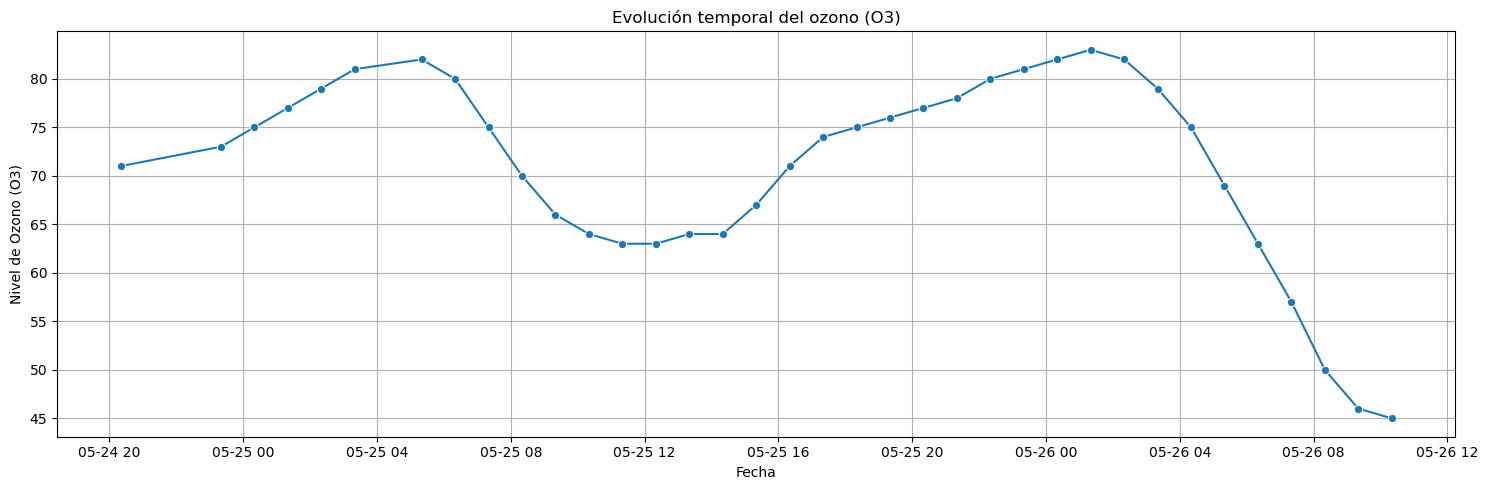

In [31]:
# Filtramos el dataset para la estación 26
estacion_o3 = pollution_dataset[pollution_dataset["objectid"] == estacion_co_max]

# Ordenamos los valores según la fecha, de más antiguo a más reciente
estacion_o3 = estacion_o3.sort_values("fecha_carga")

# Creamos la gráfica solo si existen datos válidos de O3 y fecha
if estacion_o3['o3'].notnull().any() and estacion_o3['fecha_carga'].notnull().any():
    plt.figure(figsize=(15,5))
    sns.lineplot(data=estacion_o3, x="fecha_carga", y="o3", marker="o")
    plt.xlabel("Fecha")
    plt.ylabel("Nivel de Ozono (O3)")
    plt.title("Evolución temporal del ozono (O3)")
    plt.grid()
    plt.tight_layout()
    plt.show()

else:
    print("No existen datos para esta estación")